# SAC Path Planning for IoT Data Collection

**Soft Actor-Critic (discrete)** applied to the UAV / IoT sensor environment.

- Checkpoints save to **Google Drive** so nothing is lost on disconnect
- Resume training from any saved checkpoint
- Separate evaluation section at the bottom

## 1 · Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Change this to wherever you want checkpoints saved on your Drive ──
DRIVE_CHECKPOINT_DIR = '/content/drive/MyDrive/SAC_PathPlanning/checkpoints'
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory: {DRIVE_CHECKPOINT_DIR}')

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/SAC_PathPlanning/checkpoints


## 2 · Imports & Environment Parameters

In [ ]:
import numpy as np
import math
import random
import json
import warnings
from collections import namedtuple, deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.simplefilter('ignore', UserWarning)

print('PyTorch version:', torch.__version__)
print('GPU available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name       :', torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cpu
GPU available  : False


In [ ]:
# ── Environment parameters (unchanged from original notebook) ──────────────
sigma2      = 10**-14          # noise power
W           = 20 * (10**6)     # channel bandwidth (Hz)
T_s         = 2                # duration of each time slot (s)
tau         = 0                # transmission overhead
P_max       = 0.1              # max transmit power of each sensor (W)
num_sensors = 5
data_req    = (0.4 * 10**9) * np.ones(num_sensors)  # 0.4 GB per sensor
thr         = 10               # distance threshold for data collection
B0          = 10_000_000_000   # initial energy level
v           = 5                # max UAV velocity
H           = 10               # UAV altitude
dt          = 2

## 3 · Environment

In [ ]:
class IoT_env(object):
    def __init__(self, num_sensors, initial_position, X_max, Y_max, num_actions):
        self.state0 = np.zeros((3, 11, 11))
        self.state0[0][9][1] = 1  # UAV start

        self.Obstacle_x = [0,1,1,1,1,2,4,4,4,4,5,5,5,6,8,8,8,9,9,9,9,10,10]
        self.Obstacle_y = [2,6,5,2,1,1,8,7,4,3,7,6,3,6,10,9,3,10,9,4,3,10,9]
        for i in range(len(self.Obstacle_x)):
            self.state0[1, self.Obstacle_y[i], self.Obstacle_x[i]] = 1

        self.state0[1][1][9] = 1    # terminal
        self.state0[1][2][2] = 0.5  # charging station

        self.state0[2][4][2] = 1
        self.state0[2][1][5] = 1
        self.state0[2][9][5] = 1
        self.state0[2][4][6] = 1
        self.state0[2][6][8] = 1

        self.sensors_XY      = {0:[50.,10.], 1:[20.,60.], 2:[80.,40.], 3:[60.,60.], 4:[50.,90.]}
        self.X_max           = X_max
        self.Y_max           = Y_max
        self.Collected_Data  = np.zeros(num_sensors)
        self.vector_state0   = np.asarray([10., 10.])
        self.Is_Terminal     = False
        self.vector_agentState = np.copy(self.vector_state0)
        self.agentState      = np.copy(self.state0)
        self.visited_charger = 0
        self.energy_level    = B0
        self.Terminal        = np.asarray([10., 10.])
        self.doneType        = 0
        self.max_episode_steps = 5000
        self.steps_counter   = 0
        self.num_actions     = num_actions
        self.actionspace     = {0:[0,0], 1:[v,0], 2:[0,v], 3:[-v,0], 4:[0,-v]}

    def reset(self):
        self.agentState        = np.copy(self.state0)
        self.vector_agentState = np.copy(self.vector_state0)
        self.energy_level      = B0
        self.Collected_Data    = np.zeros(num_sensors)
        self.doneType          = 0
        self.steps_counter     = 0
        self.Is_Terminal       = False
        self.visited_charger   = 0
        return self.agentState

    def step(self, action):
        V = self.actionspace[action]
        self.vector_agentState[0] = np.clip(self.vector_agentState[0] + V[0]*dt, 0, 100)
        self.vector_agentState[1] = np.clip(self.vector_agentState[1] + V[1]*dt, 0, 100)

        i_x = np.copy(self.vector_agentState[0]) / 10
        i_y = 10 - np.copy(self.vector_agentState[1]) / 10
        self.agentState = np.copy(self.state0)
        self.agentState[0][9][1] = 0
        self.agentState[0, int(i_y), int(i_x)] = 1
        self.energy_level  -= self.propulsion_power(V) * T_s
        self.steps_counter += 1
        self.Is_Terminal    = self.isTerminal()
        reward              = self.get_reward()

        data_          = np.copy(self.Collected_Data)
        data_norm      = data_ / data_req[0]
        pct            = np.clip(1 - data_norm, 0, None)
        bins           = [.1,.2,.3,.4,.5,.6,.7,.8,.9,1]
        self.agentState[2][9][5] = np.digitize(pct[0], bins, right=True) / 10
        self.agentState[2][4][2] = np.digitize(pct[1], bins, right=True) / 10
        self.agentState[2][6][8] = np.digitize(pct[2], bins, right=True) / 10
        self.agentState[2][4][6] = np.digitize(pct[3], bins, right=True) / 10
        self.agentState[2][1][5] = np.digitize(pct[4], bins, right=True) / 10
        return self.agentState, reward, self.Is_Terminal, None

    def propulsion_power(self, V):
        v_m = (np.linalg.norm(V)) ** 0.5
        return (79.85 + 0.01663*v_m**2 + 0.009242*v_m**3
                + 89.44*((1 + v_m**4/4.03**4)**0.5 - v_m**2/(2*4.03**2))**0.5)

    def isTerminal(self):
        dist = np.linalg.norm(self.vector_agentState - self.Terminal)
        if np.all(self.Collected_Data > data_req) and dist**0.5 == 0 and self.energy_level > 0:
            self.doneType = 1
            return True
        return False

    def get_reward(self):
        reward = 0
        Indicator_ = np.zeros(num_sensors)
        if self.vector_agentState[0]==20 and self.vector_agentState[1]==80 and self.visited_charger==0:
            self.visited_charger = 1
            self.energy_level    = 100_000_000
        i_x = int(self.vector_agentState[0] / 10)
        i_y = int(10 - self.vector_agentState[1] / 10)
        for i in range(len(self.Obstacle_x)):
            if self.Obstacle_x[i]==i_x and self.Obstacle_y[i]==i_y:
                reward = -20
        if not self.Is_Terminal:
            self.resourceAllocation()
            for i in range(num_sensors):
                Indicator_[i] = 0 if self.Collected_Data[i] > data_req[i] else 1
            reward += (-5 * np.sum(Indicator_)) if np.mean(Indicator_) != 0 else -1
            if self.energy_level < 0:
                reward += -100
        elif self.doneType == 1:
            reward = 10
        return reward

    def channel(self):
        D  = np.array([H**2 + (self.vector_agentState[0]-self.sensors_XY[i][0])**2
                            + (self.vector_agentState[1]-self.sensors_XY[i][1])**2
                       for i in range(num_sensors)])
        ch = 1e-3 / D
        return ch, D**0.5

    def resourceAllocation(self):
        ch, dist = self.channel()
        best = np.argmax(ch)
        if dist[best] <= thr:
            self.Collected_Data[best] += (
                np.log2(1 + P_max * ch[best] / sigma2) * W * T_s * (1 - tau)
            )

print('Environment defined.')

Environment defined.


## 4 · SAC Components

In [ ]:
# ── Replay Buffer ─────────────────────────────────────────────────────────────
Transition = namedtuple('Transition', ('state','action','next_state','reward','done'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        self.buffer.append(Transition(
            torch.from_numpy(state).float(),
            torch.tensor([action], dtype=torch.long),
            torch.from_numpy(next_state).float(),
            torch.tensor([reward], dtype=torch.float32),
            torch.tensor([done],   dtype=torch.float32),
        ))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

print('ReplayBuffer defined.')

ReplayBuffer defined.


In [ ]:
# ── Networks ──────────────────────────────────────────────────────────────────
class CNNBackbone(nn.Module):
    """Same conv architecture as the original DQN."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 4, 1)   # → (16, 8, 8)
        self.conv2 = nn.Conv2d(16, 32, 4, 1)  # → (32, 5, 5)
        self.fc    = nn.Linear(5*5*32, 64)
        self.out_dim = 64

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        return F.relu(self.fc(x))


class Actor(nn.Module):
    """Outputs a probability distribution over all discrete actions."""
    def __init__(self, n_actions):
        super().__init__()
        self.backbone = CNNBackbone()
        self.head     = nn.Linear(self.backbone.out_dim, n_actions)

    def forward(self, state):
        return F.softmax(self.head(self.backbone(state)), dim=-1)

    def get_action(self, state, deterministic=False):
        probs    = self.forward(state)
        dist     = Categorical(probs)
        action   = probs.argmax(dim=-1) if deterministic else dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, probs


class Critic(nn.Module):
    """Returns Q-values for ALL actions at once (discrete-SAC style)."""
    def __init__(self, n_actions):
        super().__init__()
        self.backbone = CNNBackbone()
        self.head     = nn.Linear(self.backbone.out_dim, n_actions)

    def forward(self, state):
        return self.head(self.backbone(state))


print('Networks defined.')

Networks defined.


In [ ]:
# ── SAC Agent ─────────────────────────────────────────────────────────────────
class SACAgent:
    def __init__(self, n_actions, replay_buffer_size=100_000, batch_size=128,
                 gamma=0.99, lr=3e-4, tau=0.005, target_entropy=None, device=None):

        self.device    = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.n_actions = n_actions
        self.batch_size= batch_size
        self.gamma     = gamma
        self.tau       = tau

        # Networks
        self.actor          = Actor(n_actions).to(self.device)
        self.critic1        = Critic(n_actions).to(self.device)
        self.critic2        = Critic(n_actions).to(self.device)
        self.target_critic1 = Critic(n_actions).to(self.device)
        self.target_critic2 = Critic(n_actions).to(self.device)
        self.target_critic1.load_state_dict(self.critic1.state_dict())
        self.target_critic2.load_state_dict(self.critic2.state_dict())
        self.target_critic1.eval()
        self.target_critic2.eval()

        # Optimizers
        self.actor_opt   = optim.Adam(self.actor.parameters(),   lr=lr)
        self.critic1_opt = optim.Adam(self.critic1.parameters(), lr=lr)
        self.critic2_opt = optim.Adam(self.critic2.parameters(), lr=lr)

        # Automatic entropy tuning
        self.target_entropy = target_entropy if target_entropy else -math.log(1.0/n_actions)
        self.log_alpha      = torch.zeros(1, requires_grad=True, device=self.device)
        self.alpha_opt      = optim.Adam([self.log_alpha], lr=lr)
        self.alpha          = self.log_alpha.exp().item()

        # Replay buffer
        self.memory = ReplayBuffer(replay_buffer_size)

    # ── Action selection ───────────────────────────────────────────────────────
    def select_action(self, state, deterministic=False):
        s = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
        with torch.no_grad():
            action, _, _ = self.actor.get_action(s, deterministic)
        return action.item()

    def store_transition(self, s, a, ns, r, done):
        self.memory.push(s, a, ns, r, done)

    # ── Update step ────────────────────────────────────────────────────────────
    def update(self):
        if len(self.memory) < self.batch_size:
            return None, None, None

        batch  = Transition(*zip(*self.memory.sample(self.batch_size)))
        states      = torch.stack(batch.state).to(self.device)
        actions     = torch.cat(batch.action).to(self.device)
        rewards     = torch.cat(batch.reward).to(self.device)
        next_states = torch.stack(batch.next_state).to(self.device)
        dones       = torch.cat(batch.done).to(self.device)

        # ── Target Q ──
        with torch.no_grad():
            next_probs    = self.actor(next_states)
            next_log_p    = torch.log(next_probs + 1e-8)
            nq1           = self.target_critic1(next_states)
            nq2           = self.target_critic2(next_states)
            soft_v        = (next_probs * (torch.min(nq1,nq2) - self.alpha*next_log_p)).sum(-1)
            target_q      = rewards + self.gamma * (1 - dones) * soft_v

        # ── Critic loss ──
        q1 = self.critic1(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        q2 = self.critic2(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        c1_loss = F.mse_loss(q1, target_q)
        c2_loss = F.mse_loss(q2, target_q)
        self.critic1_opt.zero_grad(); c1_loss.backward(); self.critic1_opt.step()
        self.critic2_opt.zero_grad(); c2_loss.backward(); self.critic2_opt.step()

        # ── Actor loss ──
        probs    = self.actor(states)
        log_p    = torch.log(probs + 1e-8)
        with torch.no_grad():
            q_min = torch.min(self.critic1(states), self.critic2(states))
        a_loss = (probs * (self.alpha * log_p - q_min)).sum(-1).mean()
        self.actor_opt.zero_grad(); a_loss.backward(); self.actor_opt.step()

        # ── Alpha loss ──
        entropy  = -(probs.detach() * log_p.detach()).sum(-1).mean()
        al_loss  = self.log_alpha * (entropy - self.target_entropy)
        self.alpha_opt.zero_grad(); al_loss.backward(); self.alpha_opt.step()
        self.alpha = self.log_alpha.exp().item()

        # ── Soft target update ──
        for p, tp in zip(self.critic1.parameters(), self.target_critic1.parameters()):
            tp.data.copy_(self.tau*p.data + (1-self.tau)*tp.data)
        for p, tp in zip(self.critic2.parameters(), self.target_critic2.parameters()):
            tp.data.copy_(self.tau*p.data + (1-self.tau)*tp.data)

        return a_loss.item(), (c1_loss+c2_loss).item()/2, self.alpha

    # ── Checkpoint I/O ─────────────────────────────────────────────────────────
    def save(self, path, episode, metrics=None):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save({
            'episode':                       episode,
            'actor_state_dict':              self.actor.state_dict(),
            'critic1_state_dict':            self.critic1.state_dict(),
            'critic2_state_dict':            self.critic2.state_dict(),
            'target_critic1_state_dict':     self.target_critic1.state_dict(),
            'target_critic2_state_dict':     self.target_critic2.state_dict(),
            'actor_opt_state_dict':          self.actor_opt.state_dict(),
            'critic1_opt_state_dict':        self.critic1_opt.state_dict(),
            'critic2_opt_state_dict':        self.critic2_opt.state_dict(),
            'alpha_opt_state_dict':          self.alpha_opt.state_dict(),
            'log_alpha':                     self.log_alpha.data,
            'metrics':                       metrics or {},
        }, path)
        print(f'  ✓ Checkpoint saved → {path}')

    def load(self, path):
        ckpt = torch.load(path, map_location=self.device, weights_only=False)
        self.actor.load_state_dict(ckpt['actor_state_dict'])
        self.critic1.load_state_dict(ckpt['critic1_state_dict'])
        self.critic2.load_state_dict(ckpt['critic2_state_dict'])
        self.target_critic1.load_state_dict(ckpt['target_critic1_state_dict'])
        self.target_critic2.load_state_dict(ckpt['target_critic2_state_dict'])
        self.actor_opt.load_state_dict(ckpt['actor_opt_state_dict'])
        self.critic1_opt.load_state_dict(ckpt['critic1_opt_state_dict'])
        self.critic2_opt.load_state_dict(ckpt['critic2_opt_state_dict'])
        self.alpha_opt.load_state_dict(ckpt['alpha_opt_state_dict'])
        self.log_alpha.data = ckpt['log_alpha']
        self.alpha = self.log_alpha.exp().item()
        start_ep = ckpt['episode'] + 1
        metrics  = ckpt.get('metrics', {})
        print(f'  ✓ Loaded {path}  →  resuming from episode {start_ep}')
        return start_ep, metrics


print('SACAgent defined.')

SACAgent defined.


## 5 · Training

- Checkpoints auto-save to **Google Drive** every `SAVE_INTERVAL` episodes
- `sac_best.pt` updates whenever the 50-episode rolling average improves
- To **resume**, set `RESUME_FROM` to the checkpoint path and re-run this cell

In [ ]:
# ── Training configuration ────────────────────────────────────────────────────
NUM_EPISODES   = 5    # total episodes this run
SAVE_INTERVAL  = 100     # save a numbered checkpoint every N episodes
# RESUME_FROM    = None    # set to a path string to resume, e.g.:
RESUME_FROM = f'{DRIVE_CHECKPOINT_DIR}/sac_ep900.pt'

# Fixed seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# ── Build environment & agent ─────────────────────────────────────────────────
env   = IoT_env(num_sensors, [10,10], 100, 100, num_actions=5)
agent = SACAgent(n_actions=5)
print(f'Device: {agent.device}')

# ── Metrics ───────────────────────────────────────────────────────────────────
cumulative_rewards = []
num_steps_list     = []
actor_losses       = []
critic_losses      = []
alphas             = []
best_avg_reward    = float('-inf')
start_episode      = 0

# ── Resume from checkpoint? ───────────────────────────────────────────────────
if RESUME_FROM is not None:
    start_episode, saved = agent.load(RESUME_FROM)

    #  # ── Override learning rates after loading ──────────────────────────
    # NEW_LR = 1e-4  # change to whatever you want
    # for opt in [agent.actor_opt, agent.critic1_opt, agent.critic2_opt, agent.alpha_opt]:
    #     for param_group in opt.param_groups:
    #         param_group['lr'] = NEW_LR
    # print(f'Learning rates overridden to {NEW_LR}')
    # # ───────────────────────────────────────────────────────────────────

    cumulative_rewards = saved.get('cumulative_rewards', [])
    num_steps_list     = saved.get('num_steps_list',     [])
    actor_losses       = saved.get('actor_losses',       [])
    critic_losses      = saved.get('critic_losses',      [])
    alphas             = saved.get('alphas',             [])
    best_avg_reward    = saved.get('best_avg_reward',    float('-inf'))

print(f'\nTraining episodes {start_episode} → {start_episode + NUM_EPISODES - 1}')
print(f'Checkpoints → {DRIVE_CHECKPOINT_DIR}/')
print('─' * 65)

# ── Main loop ─────────────────────────────────────────────────────────────────
for ep in range(start_episode, start_episode + NUM_EPISODES):
    state      = env.reset()
    done       = False
    cum_reward = 0.0
    steps      = 0
    ep_a_loss  = []
    ep_c_loss  = []

    while not done and steps < env.max_episode_steps:
        action              = agent.select_action(state)
        next_state, r, done, _ = env.step(action)
        agent.store_transition(state, action, next_state, r, done)
        result = agent.update()
        if result[0] is not None:
            ep_a_loss.append(result[0])
            ep_c_loss.append(result[1])
        state      = next_state
        cum_reward += r
        steps      += 1

    # Record
    cumulative_rewards.append(cum_reward)
    num_steps_list.append(steps)
    actor_losses.append(np.mean(ep_a_loss)  if ep_a_loss else 0.0)
    critic_losses.append(np.mean(ep_c_loss) if ep_c_loss else 0.0)
    alphas.append(agent.alpha)

    goal_tag = '  *** GOAL ***' if done else ''
    print(f'Ep {ep:4d} | reward {cum_reward:9.1f} | steps {steps:5d} | α {agent.alpha:.4f}{goal_tag}')

    # ── Checkpoint logic ──────────────────────────────────────────────────────
    metrics = dict(
        cumulative_rewards = cumulative_rewards,
        num_steps_list     = num_steps_list,
        actor_losses       = actor_losses,
        critic_losses      = critic_losses,
        alphas             = alphas,
        best_avg_reward    = best_avg_reward,
    )

    # Numbered checkpoint every SAVE_INTERVAL episodes
    if (ep + 1) % SAVE_INTERVAL == 0:
        agent.save(f'{DRIVE_CHECKPOINT_DIR}/sac_ep{ep+1}.pt', ep, metrics)

    # Best model (rolling 50-ep average)
    if len(cumulative_rewards) >= 50:
        avg50 = np.mean(cumulative_rewards[-50:])
        if avg50 > best_avg_reward:
            best_avg_reward          = avg50
            metrics['best_avg_reward'] = best_avg_reward
            agent.save(f'{DRIVE_CHECKPOINT_DIR}/sac_best.pt', ep, metrics)

# Final save
agent.save(f'{DRIVE_CHECKPOINT_DIR}/sac_final.pt', start_episode + NUM_EPISODES - 1, metrics)

# Save metrics JSON to Drive
metrics_path = f'{DRIVE_CHECKPOINT_DIR}/metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\nMetrics saved → {metrics_path}')
print('Training complete.')

Device: cpu
  ✓ Loaded /content/drive/MyDrive/SAC_PathPlanning/checkpoints/sac_ep900.pt  →  resuming from episode 900

Training episodes 900 → 904
Checkpoints → /content/drive/MyDrive/SAC_PathPlanning/checkpoints/
─────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

## 6 · Training Curves

In [ ]:
n = len(cumulative_rewards) #
eps = range(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rewards
axes[0].plot(eps, cumulative_rewards, color='royalblue', linewidth=0.7, alpha=0.5, label='per episode')
if n >= 50:
    sm = np.convolve(cumulative_rewards, np.ones(50)/50, mode='valid')
    axes[0].plot(range(49, n), sm, color='navy', linewidth=2, label='50-ep avg')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Cumulative Reward')
axes[0].set_title('Training Reward'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Steps
axes[1].plot(eps, num_steps_list, color='seagreen', linewidth=0.7, alpha=0.5)
if n >= 50:
    sm_s = np.convolve(num_steps_list, np.ones(50)/50, mode='valid')
    axes[1].plot(range(49, n), sm_s, color='darkgreen', linewidth=2, label='50-ep avg')
    axes[1].legend()
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Steps')
axes[1].set_title('Steps per Episode'); axes[1].grid(alpha=0.3)

# Actor loss + alpha
ax3 = axes[2]
ax3.plot(eps, actor_losses, color='tomato', linewidth=0.8, alpha=0.6, label='Actor loss')
ax3b = ax3.twinx()
ax3b.plot(eps, alphas, color='purple', linewidth=1, linestyle='--', alpha=0.7, label='α')
ax3b.set_ylabel('α (entropy coeff)', color='purple')
ax3b.tick_params(axis='y', labelcolor='purple')
ax3.set_xlabel('Episode'); ax3.set_ylabel('Actor Loss')
ax3.set_title('Actor Loss & Entropy Coefficient')
ax3.legend(loc='upper left'); ax3.grid(alpha=0.3)

plt.suptitle('SAC Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(f'{DRIVE_CHECKPOINT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Evaluation & Visualization

Runs the trained policy **deterministically** (no exploration) and plots:
1. The robot's trajectory on the grid
2. Data collected from each sensor over time

In [ ]:
# ── Evaluation configuration ──────────────────────────────────────────────────
EVAL_CHECKPOINT = f'{DRIVE_CHECKPOINT_DIR}/sac_ep900.pt'  # or sac_final.pt, sac_ep500.pt …
NUM_EVAL_EPISODES = 3

In [ ]:
# Load checkpoint into a fresh agent
eval_agent = SACAgent(n_actions=5)
eval_agent.load(EVAL_CHECKPOINT)
eval_agent.actor.eval()
print('Ready to evaluate.')

  ✓ Loaded /content/drive/MyDrive/SAC_PathPlanning/checkpoints/sac_ep900.pt  →  resuming from episode 900
Ready to evaluate.


Ep 1 | reward -125080.0 | steps 5000 | ✗ timeout


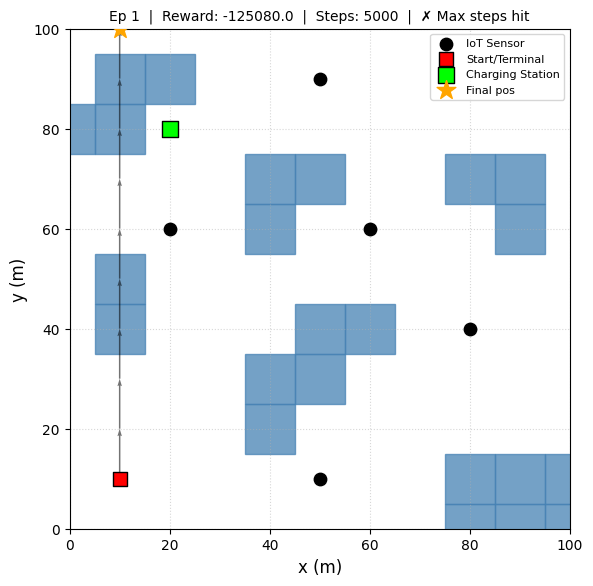

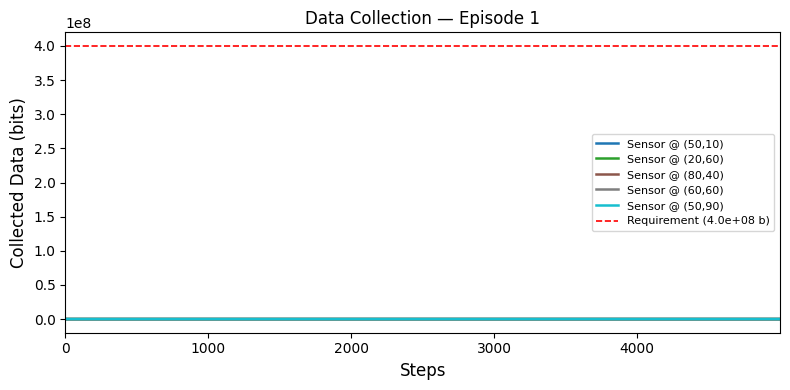

Ep 2 | reward -125080.0 | steps 5000 | ✗ timeout


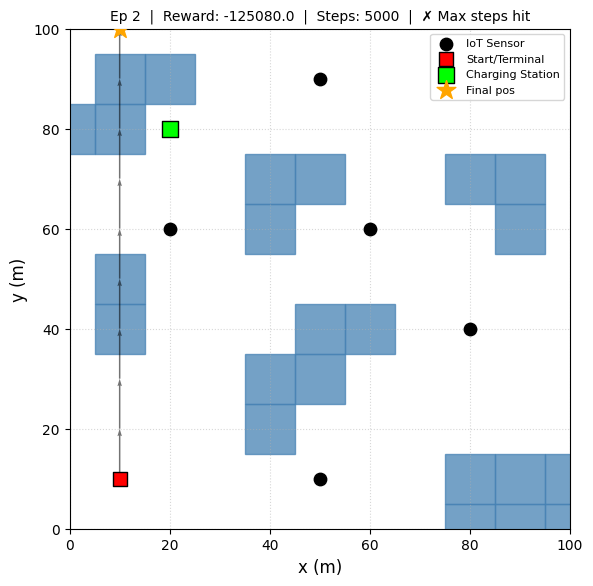

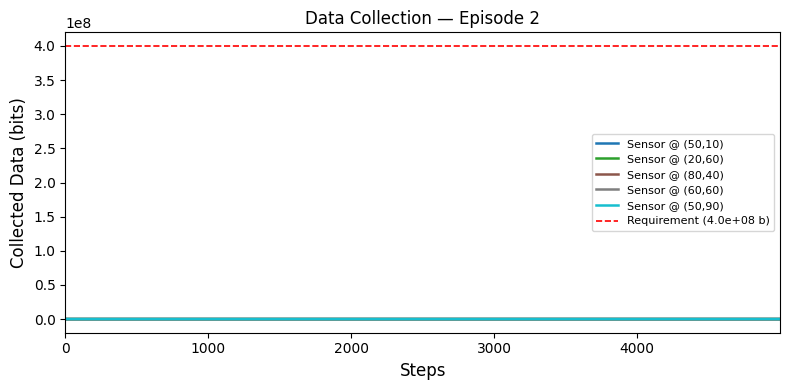

Ep 3 | reward -125080.0 | steps 5000 | ✗ timeout


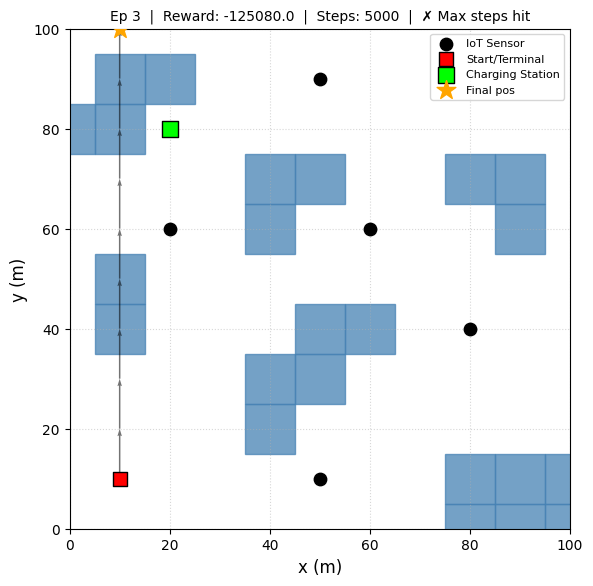

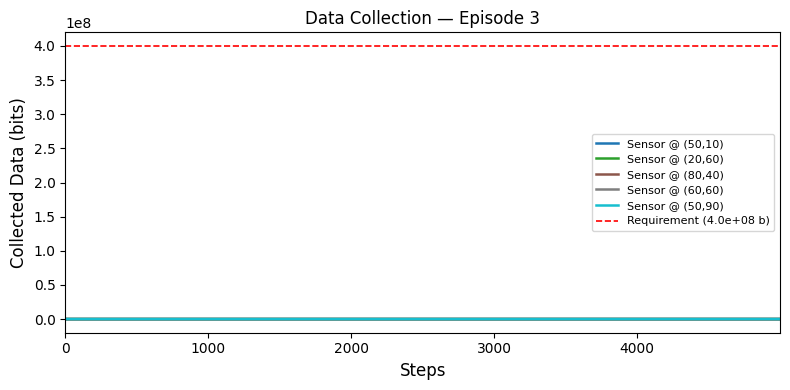


── Summary ─────────────────────────────────────────
Goal reached : 0/3 (0%)
Avg reward   : -125080.00 ± 0.00
Avg steps    : 5000.0 ± 0.0
Figures saved to /content/drive/MyDrive/SAC_PathPlanning/checkpoints/


In [ ]:
eval_env = IoT_env(num_sensors, [10,10], 100, 100, num_actions=5)

all_rewards, all_steps, goal_count = [], [], 0

for ep in range(NUM_EVAL_EPISODES):
    state      = eval_env.reset()
    done       = False
    cum_reward = 0.0
    steps      = 0
    traj_x     = [eval_env.vector_agentState[0]]
    traj_y     = [eval_env.vector_agentState[1]]
    cdt        = {i: [] for i in range(num_sensors)}

    while not done and steps < eval_env.max_episode_steps:
        action              = eval_agent.select_action(state, deterministic=True)
        next_state, r, done, _ = eval_env.step(action)
        cum_reward += r
        steps      += 1
        traj_x.append(eval_env.vector_agentState[0])
        traj_y.append(eval_env.vector_agentState[1])
        for i in range(num_sensors):
            cdt[i].append(eval_env.Collected_Data[i])
        state = next_state

    all_rewards.append(cum_reward)
    all_steps.append(steps)
    if done: goal_count += 1

    status = '✓ GOAL' if done else '✗ timeout'
    print(f'Ep {ep+1} | reward {cum_reward:.1f} | steps {steps} | {status}')

    # ── Trajectory plot ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(len(eval_env.Obstacle_x)):
        rect = plt.Rectangle(
            (10*(eval_env.Obstacle_x[i]-0.5), 10*(10-eval_env.Obstacle_y[i]-0.5)),
            10, 10, fc='steelblue', ec='steelblue', alpha=0.75)
        ax.add_patch(rect)
    x, y = np.array(traj_x), np.array(traj_y)
    if len(x) > 1:
        ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1],
                  scale_units='xy', angles='xy', scale=1,
                  color='black', alpha=0.55, width=0.003)
    sx = [eval_env.sensors_XY[i][0] for i in range(num_sensors)]
    sy = [eval_env.sensors_XY[i][1] for i in range(num_sensors)]
    ax.scatter(sx, sy,  c='black', marker='o', s=80,  zorder=5, label='IoT Sensor')
    ax.scatter(10,  10, c='red',   marker='s', s=100, zorder=6, label='Start/Terminal', ec='k')
    ax.scatter(20,  80, c='lime',  marker='s', s=120, zorder=6, label='Charging Station', ec='k')
    if traj_x:
        ax.scatter(traj_x[-1], traj_y[-1], c='orange', marker='*', s=200, zorder=7, label='Final pos')
    ax.set_xlim(0,100); ax.set_ylim(0,100); ax.set_aspect('equal')
    ax.grid(linestyle=':', alpha=0.5)
    ax.set_xlabel('x (m)', fontsize=12); ax.set_ylabel('y (m)', fontsize=12)
    goal_str = '✓ GOAL REACHED' if done else '✗ Max steps hit'
    ax.set_title(f'Ep {ep+1}  |  Reward: {cum_reward:.1f}  |  Steps: {steps}  |  {goal_str}', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_CHECKPOINT_DIR}/eval_trajectory_ep{ep+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Data collection plot ──────────────────────────────────────────────────
    if steps > 0:
        fig2, ax2 = plt.subplots(figsize=(8, 4))
        colors = plt.cm.tab10(np.linspace(0, 1, num_sensors))
        for i in range(num_sensors):
            lbl = f"Sensor @ ({eval_env.sensors_XY[i][0]:.0f},{eval_env.sensors_XY[i][1]:.0f})"
            ax2.plot(range(steps), cdt[i], color=colors[i], linewidth=1.8, label=lbl)
            ax2.fill_between(range(steps), cdt[i], 0, alpha=0.1, color=colors[i])
        ax2.axhline(data_req[0], color='red', linestyle='--', linewidth=1.2, label=f'Requirement ({data_req[0]:.1e} b)')
        ax2.set_xlabel('Steps', fontsize=12); ax2.set_ylabel('Collected Data (bits)', fontsize=12)
        ax2.set_title(f'Data Collection — Episode {ep+1}', fontsize=12)
        ax2.set_xlim(0, max(1, steps-1)); ax2.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f'{DRIVE_CHECKPOINT_DIR}/eval_data_ep{ep+1}.png', dpi=150, bbox_inches='tight')
        plt.show()

print(f'\n── Summary ─────────────────────────────────────────')
print(f'Goal reached : {goal_count}/{NUM_EVAL_EPISODES} ({100*goal_count/NUM_EVAL_EPISODES:.0f}%)')
print(f'Avg reward   : {np.mean(all_rewards):.2f} ± {np.std(all_rewards):.2f}')
print(f'Avg steps    : {np.mean(all_steps):.1f} ± {np.std(all_steps):.1f}')
print(f'Figures saved to {DRIVE_CHECKPOINT_DIR}/')

## 8 · Load & Plot Previous Training Curves

Run this cell any time — it reads `metrics.json` from Drive so you can visualise training history even after a disconnect.

In [ ]:
metrics_path = f'{DRIVE_CHECKPOINT_DIR}/metrics.json'

with open(metrics_path) as f:
    m = json.load(f)

rewards = m['cumulative_rewards']
steps   = m['num_steps_list']
a_loss  = m.get('actor_losses', [])
alp     = m.get('alphas', [])
n       = len(rewards)
eps     = range(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(eps, rewards, color='royalblue', linewidth=0.7, alpha=0.5)
if n >= 50:
    sm = np.convolve(rewards, np.ones(50)/50, mode='valid')
    axes[0].plot(range(49,n), sm, color='navy', linewidth=2, label='50-ep avg')
    axes[0].legend()
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')
axes[0].set_title('Cumulative Reward'); axes[0].grid(alpha=0.3)

axes[1].plot(eps, steps, color='seagreen', linewidth=0.7, alpha=0.5)
if n >= 50:
    sm_s = np.convolve(steps, np.ones(50)/50, mode='valid')
    axes[1].plot(range(49,n), sm_s, color='darkgreen', linewidth=2, label='50-ep avg')
    axes[1].legend()
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Steps')
axes[1].set_title('Steps per Episode'); axes[1].grid(alpha=0.3)

if a_loss:
    ax3 = axes[2]
    ax3.plot(eps, a_loss, color='tomato', linewidth=0.8, alpha=0.6, label='Actor loss')
    if alp:
        ax3b = ax3.twinx()
        ax3b.plot(eps, alp, color='purple', linewidth=1, linestyle='--', alpha=0.7)
        ax3b.set_ylabel('α', color='purple'); ax3b.tick_params(axis='y', labelcolor='purple')
    ax3.set_xlabel('Episode'); ax3.set_ylabel('Actor Loss')
    ax3.set_title('Actor Loss & α'); ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle(f'SAC Training Curves  ({n} episodes)', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Best 50-ep avg reward: {m["best_avg_reward"]:.2f}')